# DataDNA AI — Dataset Profiler

Bu notebook, tablosal veri setlerinin yapısal ve veri kalitesi özelliklerini
otomatik olarak analiz ederek bir DataDNA profili oluşturmak amacıyla geliştirilmiştir.

İncelenecek temel özellikler:

- Veri seti boyutu
- Veri tipleri
- Sayısal ve kategorik değişken oranları
- Eksik değerler
- Tekrarlı kayıtlar
- Aykırı değerler

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml

In [2]:
credit_data = fetch_openml(
    data_id=31,
    as_frame=True
)

In [3]:
df = credit_data.frame

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [4]:
df.shape


(1000, 21)

In [5]:
row_count = df.shape[0]
column_count = df.shape[1]

numeric_columns = df.select_dtypes(include="number").columns
categorical_columns = df.select_dtypes(exclude="number").columns

numeric_count = len(numeric_columns)
categorical_count = len(categorical_columns)

numeric_ratio = numeric_count / column_count
categorical_ratio = categorical_count / column_count

print("Satır sayısı:", row_count)
print("Sütun sayısı:", column_count)
print("Sayısal sütun sayısı:", numeric_count)
print("Kategorik sütun sayısı:", categorical_count)
print("Sayısal sütun oranı:", round(numeric_ratio, 3))
print("Kategorik sütun oranı:", round(categorical_ratio, 3))

Satır sayısı: 1000
Sütun sayısı: 21
Sayısal sütun sayısı: 7
Kategorik sütun sayısı: 14
Sayısal sütun oranı: 0.333
Kategorik sütun oranı: 0.667


In [6]:
missing_count = df.isna().sum().sum()
total_cells = row_count * column_count
missing_ratio = missing_count / total_cells

duplicate_count = df.duplicated().sum()
duplicate_ratio = duplicate_count / row_count

print("Toplam hücre sayısı:", total_cells)
print("Eksik değer sayısı:", missing_count)
print("Eksik değer oranı:", round(missing_ratio, 4))
print("Tekrarlı satır sayısı:", duplicate_count)
print("Tekrarlı satır oranı:", round(duplicate_ratio, 4))

Toplam hücre sayısı: 21000
Eksik değer sayısı: 0
Eksik değer oranı: 0.0
Tekrarlı satır sayısı: 0
Tekrarlı satır oranı: 0.0


In [7]:

basic_profile = {
    "row_count": row_count,
    "column_count": column_count,
    "numeric_count": numeric_count,
    "categorical_count": categorical_count,
    "numeric_ratio": round(numeric_ratio, 3),
    "categorical_ratio": round(categorical_ratio, 3),
    "missing_count": int(missing_count),
    "missing_ratio": round(missing_ratio, 4),
    "duplicate_count": int(duplicate_count),
    "duplicate_ratio": round(duplicate_ratio, 4)
}

basic_profile


{'row_count': 1000,
 'column_count': 21,
 'numeric_count': 7,
 'categorical_count': 14,
 'numeric_ratio': 0.333,
 'categorical_ratio': 0.667,
 'missing_count': 0,
 'missing_ratio': np.float64(0.0),
 'duplicate_count': 0,
 'duplicate_ratio': np.float64(0.0)}

In [8]:
outlier_counts = {}

for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_counts[column] = len(outliers)

outlier_counts

{'duration': 70,
 'credit_amount': 72,
 'installment_commitment': 0,
 'residence_since': 0,
 'age': 23,
 'existing_credits': 6,
 'num_dependents': 155}

In [9]:
outlier_counts = {}

for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_counts[column] = len(outliers)

outlier_counts

{'duration': 70,
 'credit_amount': 72,
 'installment_commitment': 0,
 'residence_since': 0,
 'age': 23,
 'existing_credits': 6,
 'num_dependents': 155}

In [10]:
total_outlier_cells = sum(outlier_counts.values())

numeric_cell_count = row_count * numeric_count

outlier_ratio = total_outlier_cells / numeric_cell_count

print("Toplam IQR aykırı değer adayı:", total_outlier_cells)
print("Sayısal hücre sayısı:", numeric_cell_count)
print("Aykırı değer hücre oranı:", round(outlier_ratio, 4))

Toplam IQR aykırı değer adayı: 326
Sayısal hücre sayısı: 7000
Aykırı değer hücre oranı: 0.0466


In [11]:
target_name = credit_data.target.name

print("Hedef değişken:", target_name)

Hedef değişken: class


In [12]:
df[target_name].value_counts()

class
good    700
bad     300
Name: count, dtype: int64

In [13]:
df[target_name].value_counts(normalize=True)

class
good    0.7
bad     0.3
Name: proportion, dtype: float64

In [14]:
total_outlier_cells = sum(outlier_counts.values())

numeric_cell_count = row_count * numeric_count
outlier_ratio = total_outlier_cells / numeric_cell_count

print("Toplam IQR aykırı değer adayı:", total_outlier_cells)
print("Sayısal hücre sayısı:", numeric_cell_count)
print("Aykırı değer hücre oranı:", round(outlier_ratio, 4))

Toplam IQR aykırı değer adayı: 326
Sayısal hücre sayısı: 7000
Aykırı değer hücre oranı: 0.0466


In [15]:
basic_profile["outlier_count"] = int(total_outlier_cells)
basic_profile["outlier_ratio"] = round(float(outlier_ratio), 4)
basic_profile["outlier_by_column"] = outlier_counts

basic_profile

{'row_count': 1000,
 'column_count': 21,
 'numeric_count': 7,
 'categorical_count': 14,
 'numeric_ratio': 0.333,
 'categorical_ratio': 0.667,
 'missing_count': 0,
 'missing_ratio': np.float64(0.0),
 'duplicate_count': 0,
 'duplicate_ratio': np.float64(0.0),
 'outlier_count': 326,
 'outlier_ratio': 0.0466,
 'outlier_by_column': {'duration': 70,
  'credit_amount': 72,
  'installment_commitment': 0,
  'residence_since': 0,
  'age': 23,
  'existing_credits': 6,
  'num_dependents': 155}}

In [16]:
target_name = credit_data.target.name

print("Hedef değişken:", target_name)
print(df[target_name].value_counts())
print(df[target_name].value_counts(normalize=True))

Hedef değişken: class
class
good    700
bad     300
Name: count, dtype: int64
class
good    0.7
bad     0.3
Name: proportion, dtype: float64


In [17]:
class_counts = df[target_name].value_counts()
class_ratios = df[target_name].value_counts(normalize=True)

majority_count = class_counts.max()
minority_count = class_counts.min()

class_balance_ratio = minority_count / majority_count

print("Sınıf sayıları:")
print(class_counts)

print("\nSınıf oranları:")
print(class_ratios)

print("\nSınıf denge oranı:", round(class_balance_ratio, 4))

Sınıf sayıları:
class
good    700
bad     300
Name: count, dtype: int64

Sınıf oranları:
class
good    0.7
bad     0.3
Name: proportion, dtype: float64

Sınıf denge oranı: 0.4286


In [18]:
basic_profile["target_column"] = target_name
basic_profile["class_count"] = len(class_counts)
basic_profile["class_distribution"] = {
    str(key): int(value)
    for key, value in class_counts.items()
}
basic_profile["class_balance_ratio"] = round(float(class_balance_ratio), 4)

basic_profile

{'row_count': 1000,
 'column_count': 21,
 'numeric_count': 7,
 'categorical_count': 14,
 'numeric_ratio': 0.333,
 'categorical_ratio': 0.667,
 'missing_count': 0,
 'missing_ratio': np.float64(0.0),
 'duplicate_count': 0,
 'duplicate_ratio': np.float64(0.0),
 'outlier_count': 326,
 'outlier_ratio': 0.0466,
 'outlier_by_column': {'duration': 70,
  'credit_amount': 72,
  'installment_commitment': 0,
  'residence_since': 0,
  'age': 23,
  'existing_credits': 6,
  'num_dependents': 155},
 'target_column': 'class',
 'class_count': 2,
 'class_distribution': {'good': 700, 'bad': 300},
 'class_balance_ratio': 0.4286}

In [19]:
def create_datadna_profile(df, target_column=None):
    row_count = df.shape[0]
    column_count = df.shape[1]

    numeric_columns = df.select_dtypes(include="number").columns
    categorical_columns = df.select_dtypes(exclude="number").columns

    numeric_count = len(numeric_columns)
    categorical_count = len(categorical_columns)

    numeric_ratio = numeric_count / column_count if column_count else 0
    categorical_ratio = categorical_count / column_count if column_count else 0

    missing_count = int(df.isna().sum().sum())
    total_cells = row_count * column_count
    missing_ratio = missing_count / total_cells if total_cells else 0

    duplicate_count = int(df.duplicated().sum())
    duplicate_ratio = duplicate_count / row_count if row_count else 0

    outlier_counts = {}

    for column in numeric_columns:
        series = df[column].dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_count = (
            (series < lower_bound) |
            (series > upper_bound)
        ).sum()

        outlier_counts[column] = int(outlier_count)

    total_outlier_cells = sum(outlier_counts.values())
    numeric_cell_count = df[numeric_columns].notna().sum().sum()

    outlier_ratio = (
        total_outlier_cells / numeric_cell_count
        if numeric_cell_count
        else 0
    )

    profile = {
        "row_count": row_count,
        "column_count": column_count,
        "numeric_count": numeric_count,
        "categorical_count": categorical_count,
        "numeric_ratio": round(float(numeric_ratio), 4),
        "categorical_ratio": round(float(categorical_ratio), 4),
        "missing_count": missing_count,
        "missing_ratio": round(float(missing_ratio), 4),
        "duplicate_count": duplicate_count,
        "duplicate_ratio": round(float(duplicate_ratio), 4),
        "outlier_count": int(total_outlier_cells),
        "outlier_ratio": round(float(outlier_ratio), 4),
        "outlier_by_column": outlier_counts
    }

    if target_column is not None:
        class_counts = df[target_column].value_counts()

        profile["target_column"] = target_column
        profile["class_count"] = len(class_counts)
        profile["class_distribution"] = {
            str(key): int(value)
            for key, value in class_counts.items()
        }

        if len(class_counts) > 1:
            profile["class_balance_ratio"] = round(
                float(class_counts.min() / class_counts.max()),
                4
            )

    return profile

In [20]:
datadna_profile = create_datadna_profile(
    df,
    target_column=target_name
)

datadna_profile

{'row_count': 1000,
 'column_count': 21,
 'numeric_count': 7,
 'categorical_count': 14,
 'numeric_ratio': 0.3333,
 'categorical_ratio': 0.6667,
 'missing_count': 0,
 'missing_ratio': 0.0,
 'duplicate_count': 0,
 'duplicate_ratio': 0.0,
 'outlier_count': 326,
 'outlier_ratio': 0.0466,
 'outlier_by_column': {'duration': 70,
  'credit_amount': 72,
  'installment_commitment': 0,
  'residence_since': 0,
  'age': 23,
  'existing_credits': 6,
  'num_dependents': 155},
 'target_column': 'class',
 'class_count': 2,
 'class_distribution': {'good': 700, 'bad': 300},
 'class_balance_ratio': 0.4286}

In [21]:
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [22]:
profile_from_module = create_datadna_profile(
    df,
    target_column=target_name
)

profile_from_module

{'row_count': 1000,
 'column_count': 21,
 'numeric_count': 7,
 'categorical_count': 14,
 'numeric_ratio': 0.3333,
 'categorical_ratio': 0.6667,
 'missing_count': 0,
 'missing_ratio': 0.0,
 'duplicate_count': 0,
 'duplicate_ratio': 0.0,
 'outlier_count': 326,
 'outlier_ratio': 0.0466,
 'outlier_by_column': {'duration': 70,
  'credit_amount': 72,
  'installment_commitment': 0,
  'residence_since': 0,
  'age': 23,
  'existing_credits': 6,
  'num_dependents': 155},
 'target_column': 'class',
 'class_count': 2,
 'class_distribution': {'good': 700, 'bad': 300},
 'class_balance_ratio': 0.4286}

In [23]:
X = df.drop(columns=[target_name])
y = df[target_name]

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

X boyutu: (1000, 20)
y boyutu: (1000,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 20)
X_test: (200, 20)
y_train: (800,)
y_test: (200,)


In [25]:
print("Train sınıf dağılımı:")
print(y_train.value_counts(normalize=True))

print("\nTest sınıf dağılımı:")
print(y_test.value_counts(normalize=True))

Train sınıf dağılımı:
class
good    0.7
bad     0.3
Name: proportion, dtype: float64

Test sınıf dağılımı:
class
good    0.7
bad     0.3
Name: proportion, dtype: float64


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [27]:
numeric_features = X.select_dtypes(include="number").columns
categorical_features = X.select_dtypes(exclude="number").columns

print("Sayısal feature sayısı:", len(numeric_features))
print("Kategorik feature sayısı:", len(categorical_features))

Sayısal feature sayısı: 7
Kategorik feature sayısı: 13


In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [29]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [30]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['bad','good']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['checking_status','duration','credit_history',...,'num_dependents', 'own_telephone','foreign_worker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [31]:
y_pred = rf_pipeline.predict(X_test)

y_pred[:10]

array(['good', 'bad', 'good', 'good', 'good', 'good', 'good', 'good',
       'bad', 'good'], dtype=object)

In [32]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred,
        labels=["bad", "good"]
    )
)

Accuracy: 0.77

Classification Report:
              precision    recall  f1-score   support

         bad       0.68      0.45      0.54        60
        good       0.79      0.91      0.85       140

    accuracy                           0.77       200
   macro avg       0.73      0.68      0.69       200
weighted avg       0.76      0.77      0.75       200


Confusion Matrix:
[[ 27  33]
 [ 13 127]]


In [33]:
balanced_rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [34]:
balanced_rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['bad','good']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['checking_status','duration','credit_history',...,'num_dependents', 'own_telephone','foreign_worker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [35]:
y_pred_balanced = balanced_rf_pipeline.predict(X_test)

In [36]:
balanced_accuracy = accuracy_score(
    y_test,
    y_pred_balanced
)

print(
    "Balanced RF Accuracy:",
    round(balanced_accuracy, 4)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_balanced,
        labels=["bad", "good"]
    )
)

Balanced RF Accuracy: 0.73

Classification Report:
              precision    recall  f1-score   support

         bad       0.55      0.57      0.56        60
        good       0.81      0.80      0.81       140

    accuracy                           0.73       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.73      0.73      0.73       200


Confusion Matrix:
[[ 34  26]
 [ 28 112]]


In [37]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        0.77,
        0.73
    ],
    "Bad Precision": [
        0.68,
        0.55
    ],
    "Bad Recall": [
        0.45,
        0.57
    ],
    "Bad F1": [
        0.54,
        0.56
    ]
})

comparison

,Model,Accuracy,Bad Precision,Bad Recall,Bad F1
0,Baseline Random Forest,0.77,0.68,0.45,0.54
1,Balanced Random Forest,0.73,0.55,0.57,0.56


In [38]:
from src.ml.random_forest_runner import (
    build_random_forest_pipeline,
    evaluate_binary_model
)

In [39]:
baseline_model = build_random_forest_pipeline(
    X_train
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_results = evaluate_binary_model(
    baseline_model,
    X_test,
    y_test
)

baseline_results

{'accuracy': 0.77,
 'precision': 0.675,
 'recall': 0.45,
 'f1_score': 0.54,
 'confusion_matrix': [[27, 33], [13, 127]]}

In [40]:
balanced_model = build_random_forest_pipeline(
    X_train,
    class_weight="balanced"
)

balanced_model.fit(
    X_train,
    y_train
)

balanced_results = evaluate_binary_model(
    balanced_model,
    X_test,
    y_test
)

balanced_results

{'accuracy': 0.73,
 'precision': 0.5484,
 'recall': 0.5667,
 'f1_score': 0.5574,
 'confusion_matrix': [[34, 26], [28, 112]]}

In [41]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        baseline_results["accuracy"],
        balanced_results["accuracy"]
    ],
    "Bad Precision": [
        baseline_results["precision"],
        balanced_results["precision"]
    ],
    "Bad Recall": [
        baseline_results["recall"],
        balanced_results["recall"]
    ],
    "Bad F1": [
        baseline_results["f1_score"],
        balanced_results["f1_score"]
    ]
})

model_comparison

,Model,Accuracy,Bad Precision,Bad Recall,Bad F1
0,Baseline Random Forest,0.77,0.6750,0.4500,0.5400
1,Balanced Random Forest,0.73,0.5484,0.5667,0.5574


In [42]:
from src.profiling.recommendation_engine import (
    generate_recommendations
)

In [43]:
recommendations = generate_recommendations(
    profile_from_module
)

for recommendation in recommendations:
    print("-", recommendation)
    

- Eksik değer problemi tespit edilmedi.
- Tekrarlı kayıt problemi tespit edilmedi.
- Sayısal değişkenlerde IQR yöntemine göre aykırı değer adayları bulunmaktadır. Bu değerler silinmeden önce değişkenlerin anlamı incelenmelidir.
- Hedef değişkende sınıf dengesizliği tespit edildi. Model değerlendirilirken yalnızca accuracy kullanılmamalı; precision, recall ve F1-score değerleri de incelenmelidir. Class weighting gibi yöntemler denenebilir.


In [44]:
from src.ml.model_interpreter import (
    compare_model_results
)

In [45]:
model_interpretations = compare_model_results(
    baseline_results,
    balanced_results,
    positive_label="bad"
)

for interpretation in model_interpretations:
    print("-", interpretation)
    

- Balanced model, bad sınıfının recall değerini 0.4500 seviyesinden 0.5667 seviyesine yükseltti.
- Balanced model kullanıldığında accuracy 0.7700 seviyesinden 0.7300 seviyesine düştü.
- bad sınıfının precision değeri düşerken, model bu sınıfı yakalama konusunda daha hassas hale geldi.
- bad sınıfının F1-score değeri 0.5400 seviyesinden 0.5574 seviyesine yükseldi.
- Sonuçlar bir performans dengesi (trade-off) olduğunu göstermektedir: azınlık sınıfını yakalama başarısı artarken genel doğruluk azalmıştır.


In [46]:
from src.reporting.report_builder import (
    build_datadna_report
)

In [47]:
datadna_report = build_datadna_report(
    profile_from_module,
    recommendations,
    baseline_results,
    balanced_results,
    model_interpretations
)

datadna_report

{'dataset_profile': {'row_count': 1000,
  'column_count': 21,
  'numeric_count': 7,
  'categorical_count': 14,
  'numeric_ratio': 0.3333,
  'categorical_ratio': 0.6667,
  'missing_count': 0,
  'missing_ratio': 0.0,
  'duplicate_count': 0,
  'duplicate_ratio': 0.0,
  'outlier_count': 326,
  'outlier_ratio': 0.0466,
  'outlier_by_column': {'duration': 70,
   'credit_amount': 72,
   'installment_commitment': 0,
   'residence_since': 0,
   'age': 23,
   'existing_credits': 6,
   'num_dependents': 155},
  'target_column': 'class',
  'class_count': 2,
  'class_distribution': {'good': 700, 'bad': 300},
  'class_balance_ratio': 0.4286},
 'data_recommendations': ['Eksik değer problemi tespit edilmedi.',
  'Tekrarlı kayıt problemi tespit edilmedi.',
  'Sayısal değişkenlerde IQR yöntemine göre aykırı değer adayları bulunmaktadır. Bu değerler silinmeden önce değişkenlerin anlamı incelenmelidir.',
  'Hedef değişkende sınıf dengesizliği tespit edildi. Model değerlendirilirken yalnızca accuracy kulla

In [48]:
from src.reporting.report_formatter import (
    format_datadna_report
)

In [49]:
formatted_report = format_datadna_report(
    datadna_report
)

print(formatted_report)

DATADNA AI - ANALYSIS REPORT

1. DATASET STRUCTURE
-------------------------------------------------------
Row Count: 1000
Column Count: 21
Numeric Columns: 7
Categorical Columns: 14
Numeric Ratio: 33.33%
Categorical Ratio: 66.67%

2. DATA QUALITY
-------------------------------------------------------
Missing Value Ratio: 0.00%
Duplicate Row Ratio: 0.00%
IQR Outlier Candidate Ratio: 4.66%

3. TARGET ANALYSIS
-------------------------------------------------------
Target Column: class
Number of Classes: 2
good: 700
bad: 300
Class Balance Ratio: 0.4286

4. DATA RECOMMENDATIONS
-------------------------------------------------------
- Eksik değer problemi tespit edilmedi.
- Tekrarlı kayıt problemi tespit edilmedi.
- Sayısal değişkenlerde IQR yöntemine göre aykırı değer adayları bulunmaktadır. Bu değerler silinmeden önce değişkenlerin anlamı incelenmelidir.
- Hedef değişkende sınıf dengesizliği tespit edildi. Model değerlendirilirken yalnızca accuracy kullanılmamalı; precision, recall ve 

In [50]:
report_path = project_root / "reports" / "datadna_analysis_report.txt"

with open(
    report_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(formatted_report)

print("Rapor kaydedildi:")
print(report_path)

Rapor kaydedildi:
C:\Users\CASPER\Desktop\DataDNA-Aİ\reports\datadna_analysis_report.txt


In [51]:
import json

In [52]:
json_report_path = (
    project_root
    / "reports"
    / "datadna_analysis_report.json"
)

with open(
    json_report_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        datadna_report,
        file,
        ensure_ascii=False,
        indent=4
    )

print("JSON raporu kaydedildi:")
print(json_report_path)

JSON raporu kaydedildi:
C:\Users\CASPER\Desktop\DataDNA-Aİ\reports\datadna_analysis_report.json


In [53]:
from src.datadna_pipeline import (
    run_datadna_analysis
)

In [54]:
result = run_datadna_analysis(
    df,
    target_column="class",
    positive_label="bad",
    negative_label="good"
)

In [55]:
print(result["formatted_report"])

DATADNA AI - ANALYSIS REPORT

1. DATASET STRUCTURE
-------------------------------------------------------
Row Count: 1000
Column Count: 21
Numeric Columns: 7
Categorical Columns: 13
Numeric Ratio: 35.00%
Categorical Ratio: 65.00%

2. DATA QUALITY
-------------------------------------------------------
Missing Value Ratio: 0.00%
Duplicate Row Ratio: 0.00%
IQR Outlier Candidate Ratio: 4.66%

3. TARGET ANALYSIS
-------------------------------------------------------
Target Column: class
Number of Classes: 2
good: 700
bad: 300
Class Balance Ratio: 0.4286

4. DATA RECOMMENDATIONS
-------------------------------------------------------
- Eksik değer problemi tespit edilmedi.
- Tekrarlı kayıt problemi tespit edilmedi.
- Sayısal değişkenlerde IQR yöntemine göre aykırı değer adayları bulunmaktadır. Bu değerler silinmeden önce değişkenlerin anlamı incelenmelidir.
- Hedef değişkende sınıf dengesizliği tespit edildi. Model değerlendirilirken yalnızca accuracy kullanılmamalı; precision, recall ve 

In [56]:
from sklearn.datasets import load_breast_cancer

cancer_data = load_breast_cancer(
    as_frame=True
)

cancer_df = cancer_data.frame

cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [57]:
cancer_df.shape

(569, 31)

In [58]:
cancer_data.target.name

'target'

In [59]:
cancer_df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [60]:
cancer_df["target"].value_counts(normalize=True)


target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

In [61]:
import importlib
import src.profiling.dna_builder

importlib.reload(
    src.profiling.dna_builder
)

<module 'src.profiling.dna_builder' from 'C:\\Users\\CASPER\\Desktop\\DataDNA-Aİ\\src\\profiling\\dna_builder.py'>

In [62]:
cancer_data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [63]:
import src.datadna_pipeline

importlib.reload(
    src.datadna_pipeline
)

from src.datadna_pipeline import (
    run_datadna_analysis
)

In [64]:
cancer_result = run_datadna_analysis(
    cancer_df,
    target_column="target",
    positive_label=0,
    negative_label=1,
    save_reports=False
)

In [65]:
print(
    cancer_result["formatted_report"]
)

DATADNA AI - ANALYSIS REPORT

1. DATASET STRUCTURE
-------------------------------------------------------
Row Count: 569
Column Count: 31
Numeric Columns: 30
Categorical Columns: 0
Numeric Ratio: 100.00%
Categorical Ratio: 0.00%

2. DATA QUALITY
-------------------------------------------------------
Missing Value Ratio: 0.00%
Duplicate Row Ratio: 0.00%
IQR Outlier Candidate Ratio: 3.56%

3. TARGET ANALYSIS
-------------------------------------------------------
Target Column: target
Number of Classes: 2
1: 357
0: 212
Class Balance Ratio: 0.5938

4. DATA RECOMMENDATIONS
-------------------------------------------------------
- Eksik değer problemi tespit edilmedi.
- Tekrarlı kayıt problemi tespit edilmedi.
- Sayısal değişkenlerde IQR yöntemine göre aykırı değer adayları bulunmaktadır. Bu değerler silinmeden önce değişkenlerin anlamı incelenmelidir.
- Hedef değişkende sınıf dengesizliği tespit edildi. Model değerlendirilirken yalnızca accuracy kullanılmamalı; precision, recall ve F1-sc

In [66]:
import importlib
import src.datadna_pipeline

importlib.reload(
    src.datadna_pipeline
)

from src.datadna_pipeline import (
    run_datadna_analysis
)

In [67]:
cancer_result = run_datadna_analysis(
    cancer_df,
    target_column="target",
    positive_label=0,
    negative_label=1,
    class_names={
        0: "malignant",
        1: "benign"
    },
    save_reports=False
)

In [68]:
import importlib

import src.profiling.dna_builder
import src.datadna_pipeline

importlib.reload(
    src.profiling.dna_builder
)

importlib.reload(
    src.datadna_pipeline
)

from src.datadna_pipeline import (
    run_datadna_analysis
)

In [69]:
cancer_result = run_datadna_analysis(
    cancer_df,
    target_column="target",
    positive_label=0,
    negative_label=1,
    class_names={
        0: "malignant",
        1: "benign"
    },
    save_reports=False
)

In [70]:
print(
    cancer_result["formatted_report"]
)

DATADNA AI - ANALYSIS REPORT

1. DATASET STRUCTURE
-------------------------------------------------------
Row Count: 569
Column Count: 31
Numeric Columns: 30
Categorical Columns: 0
Numeric Ratio: 100.00%
Categorical Ratio: 0.00%

2. DATA QUALITY
-------------------------------------------------------
Missing Value Ratio: 0.00%
Duplicate Row Ratio: 0.00%
IQR Outlier Candidate Ratio: 3.56%

3. TARGET ANALYSIS
-------------------------------------------------------
Target Column: target
Number of Classes: 2
benign: 357
malignant: 212
Class Balance Ratio: 0.5938

4. DATA RECOMMENDATIONS
-------------------------------------------------------
- Eksik değer problemi tespit edilmedi.
- Tekrarlı kayıt problemi tespit edilmedi.
- Sayısal değişkenlerde IQR yöntemine göre aykırı değer adayları bulunmaktadır. Bu değerler silinmeden önce değişkenlerin anlamı incelenmelidir.
- Hedef değişkende sınıf dengesizliği tespit edildi. Model değerlendirilirken yalnızca accuracy kullanılmamalı; precision, re

In [71]:
credit_result = run_datadna_analysis(
    df,
    target_column="class",
    positive_label="bad",
    negative_label="good",
    save_reports=False
)

In [72]:
print(
    credit_result["formatted_report"]
)

DATADNA AI - ANALYSIS REPORT

1. DATASET STRUCTURE
-------------------------------------------------------
Row Count: 1000
Column Count: 21
Numeric Columns: 7
Categorical Columns: 13
Numeric Ratio: 35.00%
Categorical Ratio: 65.00%

2. DATA QUALITY
-------------------------------------------------------
Missing Value Ratio: 0.00%
Duplicate Row Ratio: 0.00%
IQR Outlier Candidate Ratio: 4.66%

3. TARGET ANALYSIS
-------------------------------------------------------
Target Column: class
Number of Classes: 2
good: 700
bad: 300
Class Balance Ratio: 0.4286

4. DATA RECOMMENDATIONS
-------------------------------------------------------
- Eksik değer problemi tespit edilmedi.
- Tekrarlı kayıt problemi tespit edilmedi.
- Sayısal değişkenlerde IQR yöntemine göre aykırı değer adayları bulunmaktadır. Bu değerler silinmeden önce değişkenlerin anlamı incelenmelidir.
- Hedef değişkende sınıf dengesizliği tespit edildi. Model değerlendirilirken yalnızca accuracy kullanılmamalı; precision, recall ve 

In [73]:
from src.profiling.fingerprint_builder import (
    create_dataset_fingerprint
)


In [74]:
credit_fingerprint = create_dataset_fingerprint(
    credit_result["report"]["dataset_profile"]
)

credit_fingerprint


{'row_count': 1000,
 'feature_count': 20,
 'numeric_ratio': 0.35,
 'categorical_ratio': 0.65,
 'missing_ratio': 0.0,
 'duplicate_ratio': 0.0,
 'outlier_ratio': 0.0466,
 'class_balance_ratio': 0.4286}

In [75]:
cancer_fingerprint = create_dataset_fingerprint(
    cancer_result["report"]["dataset_profile"]
)

cancer_fingerprint

{'row_count': 569,
 'feature_count': 30,
 'numeric_ratio': 1.0,
 'categorical_ratio': 0.0,
 'missing_ratio': 0.0,
 'duplicate_ratio': 0.0,
 'outlier_ratio': 0.0356,
 'class_balance_ratio': 0.5938}

In [76]:
fingerprint_comparison = pd.DataFrame(
    [
        credit_fingerprint,
        cancer_fingerprint
    ],
    index=[
        "German Credit",
        "Breast Cancer"
    ]
)

fingerprint_comparison

,row_count,feature_count,numeric_ratio,categorical_ratio,missing_ratio,duplicate_ratio,outlier_ratio,class_balance_ratio
German Credit,1000,20,0.35,0.65,0.0,0.0,0.0466,0.4286
Breast Cancer,569,30,1.00,0.00,0.0,0.0,0.0356,0.5938


In [77]:
import importlib
import src.profiling.meta_dataset_builder as meta_builder

importlib.reload(meta_builder)

<module 'src.profiling.meta_dataset_builder' from 'C:\\Users\\CASPER\\Desktop\\DataDNA-Aİ\\src\\profiling\\meta_dataset_builder.py'>

In [78]:
hasattr(
    meta_builder,
    "build_meta_dataset"
)

True

In [79]:
fingerprints = {
    "German Credit": credit_fingerprint,
    "Breast Cancer": cancer_fingerprint
}

meta_dataset = meta_builder.build_meta_dataset(
    fingerprints
)

meta_dataset

KeyError: 'fingerprint'

In [ ]:
credit_result["report"]["model_results"]

In [ ]:
import importlib
import src.profiling.meta_dataset_builder as meta_builder

importlib.reload(
    meta_builder
)

In [ ]:
dataset_records = {
    "German Credit": {
        "fingerprint": credit_fingerprint,
        "model_results": credit_result[
            "report"
        ]["model_results"]
    },

    "Breast Cancer": {
        "fingerprint": cancer_fingerprint,
        "model_results": cancer_result[
            "report"
        ]["model_results"]
    }
}

In [ ]:
meta_dataset = meta_builder.build_meta_dataset(
    dataset_records
)

meta_dataset

In [ ]:
meta_dataset[
    [
        "dataset_name",
        "class_balance_ratio",
        "baseline_accuracy",
        "balanced_accuracy",
        "baseline_recall",
        "balanced_recall",
        "recall_gain",
        "accuracy_change",
        "f1_change"
    ]
]

In [ ]:
from sklearn.datasets import fetch_openml

diabetes_data = fetch_openml(
    data_id=37,
    as_frame=True
)

diabetes_df = diabetes_data.frame

In [ ]:
from sklearn.datasets import load_iris

iris_data = load_iris(
    as_frame=True
)

iris_df = iris_data.frame

iris_df.head()

In [ ]:
iris_df.shape

In [ ]:
iris_data.target_names

In [ ]:
iris_binary_df = iris_df[
    iris_df["target"].isin([1, 2])
].copy()

iris_binary_df.head()

In [ ]:
iris_binary_df.shape

In [ ]:
iris_binary_df["target"].value_counts()

In [ ]:
iris_result = run_datadna_analysis(
    iris_binary_df,
    target_column="target",
    positive_label=2,
    negative_label=1,
    class_names={
        1: "versicolor",
        2: "virginica"
    },
    save_reports=False
)

In [ ]:
print(
    iris_result["formatted_report"]
)

In [ ]:
import importlib

import src.ml.model_interpreter
import src.datadna_pipeline

importlib.reload(
    src.ml.model_interpreter
)

importlib.reload(
    src.datadna_pipeline
)

from src.datadna_pipeline import (
    run_datadna_analysis
)

In [ ]:
iris_result = run_datadna_analysis(
    iris_binary_df,
    target_column="target",
    positive_label=2,
    negative_label=1,
    class_names={
        1: "versicolor",
        2: "virginica"
    },
    save_reports=False
)

In [ ]:
print(
    iris_result["formatted_report"]
)

In [ ]:
iris_fingerprint = create_dataset_fingerprint(
    iris_result["report"]["dataset_profile"]
)

iris_fingerprint

In [ ]:
dataset_records = {
    "German Credit": {
        "fingerprint": credit_fingerprint,
        "model_results": credit_result[
            "report"
        ]["model_results"]
    },

    "Breast Cancer": {
        "fingerprint": cancer_fingerprint,
        "model_results": cancer_result[
            "report"
        ]["model_results"]
    },

    "Iris Binary": {
        "fingerprint": iris_fingerprint,
        "model_results": iris_result[
            "report"
        ]["model_results"]
    }
}

In [ ]:
meta_dataset = meta_builder.build_meta_dataset(
    dataset_records
)

meta_dataset

In [ ]:
meta_dataset[
    [
        "dataset_name",
        "class_balance_ratio",
        "baseline_accuracy",
        "balanced_accuracy",
        "baseline_recall",
        "balanced_recall",
        "recall_gain",
        "accuracy_change",
        "f1_change"
    ]
]

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    meta_dataset["class_balance_ratio"],
    meta_dataset["recall_gain"],
    s=100
)

for _, row in meta_dataset.iterrows():
    plt.annotate(
        row["dataset_name"],
        (
            row["class_balance_ratio"],
            row["recall_gain"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Class Balance Ratio")
plt.ylabel("Recall Gain")
plt.title(
    "Dataset Class Balance vs Balanced Random Forest Recall Gain"
)

plt.grid(alpha=0.3)

plt.show()

In [ ]:
meta_dataset_path = (
    project_root
    / "data"
    / "processed"
    / "datadna_meta_dataset.csv"
)

meta_dataset.to_csv(
    meta_dataset_path,
    index=False
)

print("Meta-dataset kaydedildi:")
print(meta_dataset_path)

In [ ]:
from sklearn.datasets import load_digits

digits_data = load_digits(
    as_frame=True
)

digits_df = digits_data.frame

digits_df.head()


In [ ]:
digits_df.shape

In [ ]:
digits_data.target_names

In [ ]:
digits_binary_df = digits_df[
    digits_df["target"].isin([0, 1])
].copy()

digits_binary_df.shape

In [ ]:
digits_binary_df["target"].value_counts()

In [ ]:
digits_result = run_datadna_analysis(
    digits_binary_df,
    target_column="target",
    positive_label=1,
    negative_label=0,
    class_names={
        0: "digit_0",
        1: "digit_1"
    },
    save_reports=False
)

In [ ]:
print(
    digits_result["formatted_report"]
)

In [ ]:
digits_fingerprint = create_dataset_fingerprint(
    digits_result["report"]["dataset_profile"]
)

digits_fingerprint

In [ ]:
dataset_records = {
    "German Credit": {
        "fingerprint": credit_fingerprint,
        "model_results": credit_result[
            "report"
        ]["model_results"]
    },

    "Breast Cancer": {
        "fingerprint": cancer_fingerprint,
        "model_results": cancer_result[
            "report"
        ]["model_results"]
    },

    "Iris Binary": {
        "fingerprint": iris_fingerprint,
        "model_results": iris_result[
            "report"
        ]["model_results"]
    },

    "Digits Binary": {
        "fingerprint": digits_fingerprint,
        "model_results": digits_result[
            "report"
        ]["model_results"]
    }
}

In [ ]:
meta_dataset = meta_builder.build_meta_dataset(
    dataset_records
)

meta_dataset

In [ ]:
meta_dataset[
    [
        "dataset_name",
        "feature_count",
        "class_balance_ratio",
        "baseline_accuracy",
        "balanced_accuracy",
        "baseline_recall",
        "balanced_recall",
        "recall_gain",
        "accuracy_change",
        "f1_change"
    ]
]

In [ ]:
meta_dataset.to_csv(
    meta_dataset_path,
    index=False
)

print("Güncellenmiş meta-dataset kaydedildi.")
print("Toplam veri seti:", len(meta_dataset))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    meta_dataset["class_balance_ratio"],
    meta_dataset["recall_gain"],
    s=100
)

label_offsets = {
    "German Credit": (6, 6),
    "Breast Cancer": (6, 6),
    "Iris Binary": (-65, 12),
    "Digits Binary": (8, -18)
}

for _, row in meta_dataset.iterrows():
    offset = label_offsets.get(
        row["dataset_name"],
        (6, 6)
    )

    plt.annotate(
        row["dataset_name"],
        (
            row["class_balance_ratio"],
            row["recall_gain"]
        ),
        xytext=offset,
        textcoords="offset points"
    )

plt.xlabel("Class Balance Ratio")
plt.ylabel("Recall Gain")

plt.title(
    "Dataset Class Balance vs Balanced Random Forest Recall Gain"
)

plt.grid(alpha=0.3)

plt.show()

In [ ]:
from src.intelligence.meta_analyzer import (
    analyze_meta_dataset
)

In [ ]:
meta_insights = analyze_meta_dataset(
    meta_dataset
)

meta_insights

In [ ]:
for insight in meta_insights:
    print("-", insight)

In [ ]:
meta_report_path = (
    project_root
    / "reports"
    / "datadna_meta_analysis.txt"
)

with open(
    meta_report_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "DATADNA AI - META ANALYSIS REPORT\n"
    )

    file.write(
        "=" * 55 + "\n\n"
    )

    for insight in meta_insights:
        file.write(
            f"- {insight}\n"
        )

print("Meta analiz raporu kaydedildi:")
print(meta_report_path)


In [82]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Projenin ana klasörünü bul
project_root = Path.cwd().parent

# Dün kaydettiğimiz meta-dataset dosyasının yolu
meta_dataset_path = (
    project_root
    / "data"
    / "processed"
    / "datadna_meta_dataset.csv"
)

# Meta-dataset'i tekrar belleğe yükle
meta_dataset = pd.read_csv(
    meta_dataset_path
)

print("Meta-dataset yeniden yüklendi.")
print("Toplam veri seti:", len(meta_dataset))

meta_dataset

Meta-dataset yeniden yüklendi.
Toplam veri seti: 4


,dataset_name,row_count,feature_count,numeric_ratio,categorical_ratio,missing_ratio,duplicate_ratio,outlier_ratio,class_balance_ratio,baseline_accuracy,balanced_accuracy,baseline_recall,balanced_recall,baseline_f1,balanced_f1,recall_gain,accuracy_change,f1_change
0,German Credit,1000,20,0.35,0.65,0.0,0.00,0.0466,0.4286,0.7700,0.7300,0.4500,0.5667,0.5400,0.5574,0.1167,-0.0400,0.0174
1,Breast Cancer,569,30,1.00,0.00,0.0,0.00,0.0356,0.5938,0.9561,0.9474,0.9286,0.9524,0.9398,0.9302,0.0238,-0.0087,-0.0096
2,Iris Binary,100,4,1.00,0.00,0.0,0.01,0.0175,1.0000,0.8000,0.8000,0.7000,0.7000,0.7778,0.7778,0.0000,0.0000,0.0000
3,Digits Binary,360,64,1.00,0.00,0.0,0.00,0.0255,0.9780,0.9722,0.9722,0.9444,0.9444,0.9714,0.9714,0.0000,0.0000,0.0000


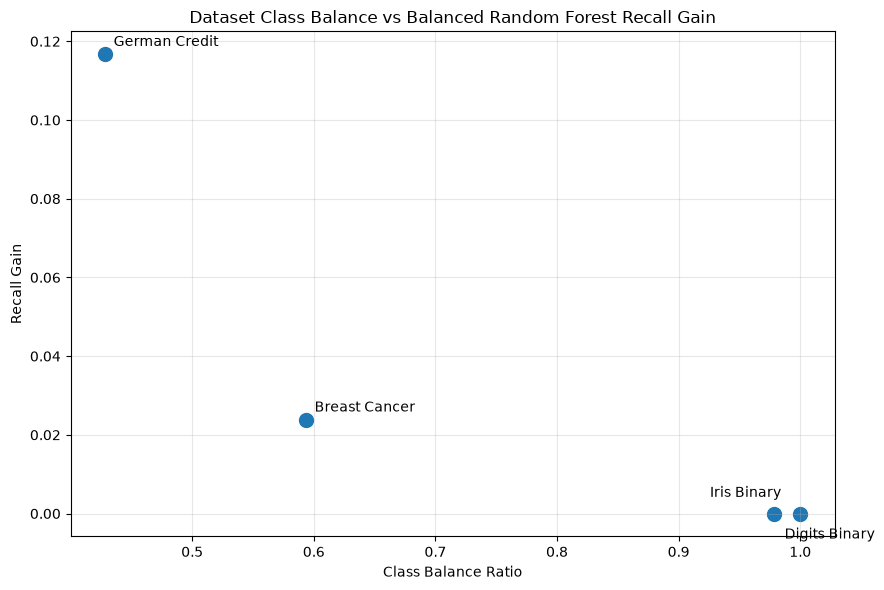

Grafik kaydedildi:
C:\Users\CASPER\Desktop\DataDNA-Aİ\reports\figures\class_balance_vs_recall_gain.png


In [83]:
from pathlib import Path
import matplotlib.pyplot as plt

figures_directory = (
    project_root
    / "reports"
    / "figures"
)

figures_directory.mkdir(
    parents=True,
    exist_ok=True
)

figure_path = (
    figures_directory
    / "class_balance_vs_recall_gain.png"
)

plt.figure(figsize=(9, 6))

plt.scatter(
    meta_dataset["class_balance_ratio"],
    meta_dataset["recall_gain"],
    s=100
)

label_offsets = {
    "German Credit": (6, 6),
    "Breast Cancer": (6, 6),
    "Iris Binary": (-65, 12),
    "Digits Binary": (8, -18)
}

for _, row in meta_dataset.iterrows():
    offset = label_offsets.get(
        row["dataset_name"],
        (6, 6)
    )

    plt.annotate(
        row["dataset_name"],
        (
            row["class_balance_ratio"],
            row["recall_gain"]
        ),
        xytext=offset,
        textcoords="offset points"
    )

plt.xlabel("Class Balance Ratio")
plt.ylabel("Recall Gain")

plt.title(
    "Dataset Class Balance vs Balanced Random Forest Recall Gain"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Grafik kaydedildi:")
print(figure_path)

In [84]:
from pathlib import Path

project_root = Path.cwd().parent

meta_dataset_path = (
    project_root
    / "data"
    / "processed"
    / "datadna_meta_dataset.csv"
)

meta_report_path = (
    project_root
    / "reports"
    / "datadna_meta_analysis.txt"
)

figure_path = (
    project_root
    / "reports"
    / "figures"
    / "class_balance_vs_recall_gain.png"
)

print("=== DATADNA-Aİ FINAL KONTROL ===")

print("\nMeta-dataset:")
print("Var mı? ->", meta_dataset_path.exists())

print("\nMeta analiz raporu:")
print("Var mı? ->", meta_report_path.exists())

print("\nFinal grafik:")
print("Var mı? ->", figure_path.exists())

print("\nMeta-dataset içindeki veri seti sayısı:")
print(len(meta_dataset))

print("\nVeri setleri:")
for dataset_name in meta_dataset["dataset_name"]:
    print("-", dataset_name)

=== DATADNA-Aİ FINAL KONTROL ===

Meta-dataset:
Var mı? -> True

Meta analiz raporu:
Var mı? -> True

Final grafik:
Var mı? -> True

Meta-dataset içindeki veri seti sayısı:
4

Veri setleri:
- German Credit
- Breast Cancer
- Iris Binary
- Digits Binary
